#**Simulation and Modeling of Temporally Oriented Systems**

```
INF301 – System Modeling and Simulation
Prof. Luiz Henrique Bonani
Week 06
```



# Temporal Systems

Nature, whether physical or biological, is the source of a large number of interesting, yet non-trivial, models.

The phenomena that form the basis of these models are not only crucial to systems engineers, but are fascinating in their own right.

Important properties characterize these natural models:
* They are based on continuous time, and their models are described mathematically by differential equations.
* They are autonomous or have time-dependent inputs.
* They are generally physical or biological systems, and are described by differential or difference equations.

Although the system mechanisms are often well-behaved, the signals that drive the system are often not. This behavior presents a challenge for scientists, engineers, and model developers, who usually simplify the system model to make its description feasible.

Thus, the central idea in modeling natural systems is the precise formulation of a mathematical description, typically a set of differential equations.

# Modeling Input Signals

Ultimately, it is the input signals that drive the systems. In temporal systems, the inputs appear on the right-hand side of the equations, which describe the dynamics of the outputs, as illustrated in the example of the following equations.

$$ \ddot{z} + 2\dot{z} +4z = x$$ $$ \ddot{z} + 2\dot{z} +4z = x + 2\dot{x}$$ $$ \ddot{z} + 2\dot{z} +4z = x + 3tx$$

It is often necessary to use relational notation to write composite functions.

## Example 1
Consider the idealized periodic signal shown in the figure below.

Using a relational function, write a formula for this signal.

<center>

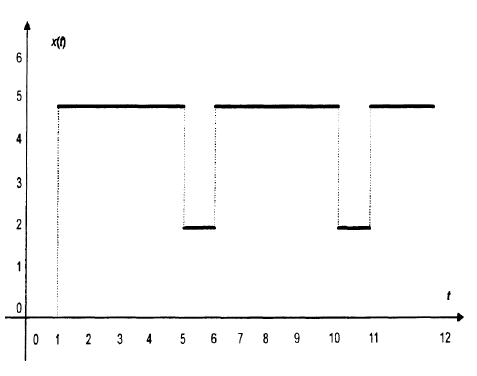
</center>

**Solution**:

Note that starting at time t = 1, the signal is periodic with a period of 5, being high 80% of the time and low 20% of the time. Thus, for the interval 1 ≤ t < 6, we can write:

$$x_1(t)=
\begin{cases}
  5 & 1 \le t \lt 5, \\    
  2 & 5 \le t \lt 6.    
\end{cases} =3[(t\gt 1)~\mathrm{AND}~(t\lt5)]+2
$$

Rewriting as a function, one can generalize the period to determine the pulse value as a function of t:

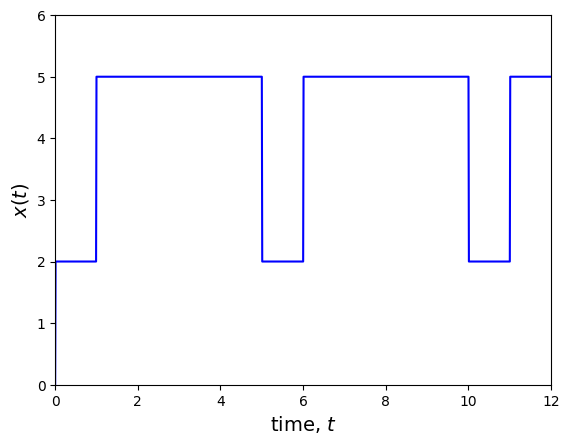

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.01; Z = 12; T = int(Z/h)


def pulse(t):
  x = 3*(1*( ((t%5) > 1)  and ( (t%5) < 5) )) + 2 # product of
  return x            # a boolean returns the integers 0 or 1

t = np.zeros(T); x = np.zeros(T)

for i in range(1,T):
    t[i] = t[i-1] + h
    x[i] = pulse(t[i])

# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-")
plt.xlabel("time, $t$",fontsize=14)
plt.ylabel(r"$x(t)$",fontsize=14)
plt.axis([0, 12, 0, 6])
plt.show()


# Additive Noise

In the case of theoretical analysis, white noise can be added at each instant of time, as seen before. By definition, white noise is frequency-independent and has an infinite bandwidth.

<center>

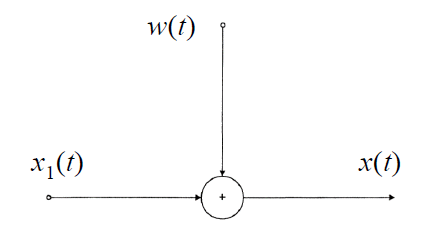
</center>
Therefore, especially when dealing with signals in the presence of noise, it is common to pass them through low-pass filters (LPF) before inputting them into the system.

This device removes most of the imperfections and makes the sampling process more accurate.

# RC Filter

The RC type LPF (Low-pass filter) is the simplest possible. This filter is constructed using a resistor and a capacitor. The value of R and C constitutes the time constant of the filter $\tau = RC$.




<center>

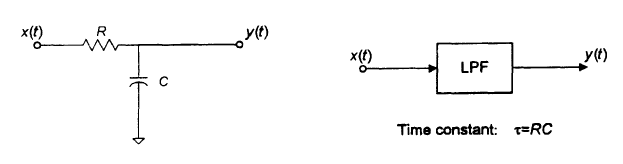

</center>

The differential equation that defines the relationship between input and output is:

$$ \tau\frac{\partial y}{\partial t}+y(t) = x(t)$$

Assuming an integration step $h$, Euler's formula reduces to:

$$ y^{new} = y + \frac{h}{\tau}[x(t)-y(t)]$$

## Example 2

Consider an input $x(t)$ that is preprocessed using an LPF, producing an output $y(t)$, as shown in the figure.

The Signal $x_1$(t) is the same as that given in Example 1, and $w(t)$ is a Gaussian noise with variance 4.

Test the filter for $\tau = 0.5, 1.0$, and $1.5$.



<center>

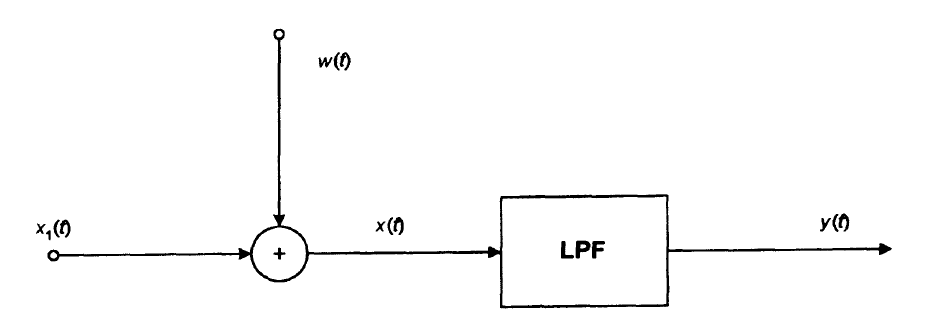
</center>

**Solution**:

The script to build the simulation, as well as its result, are shown below:

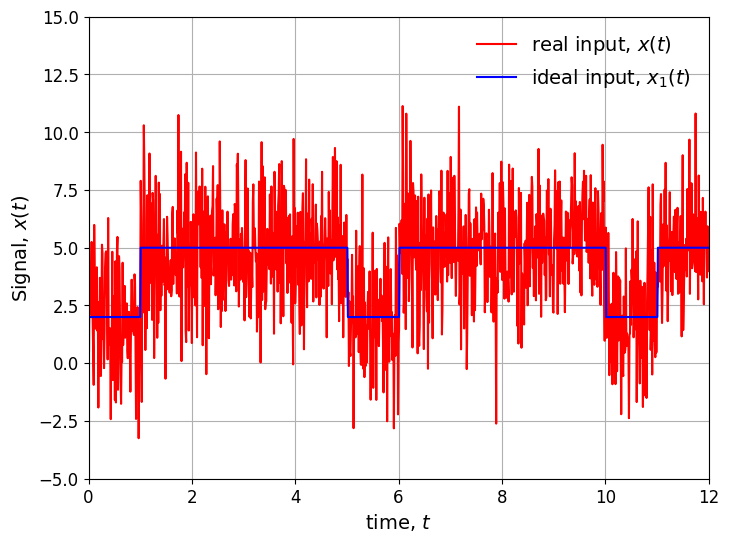

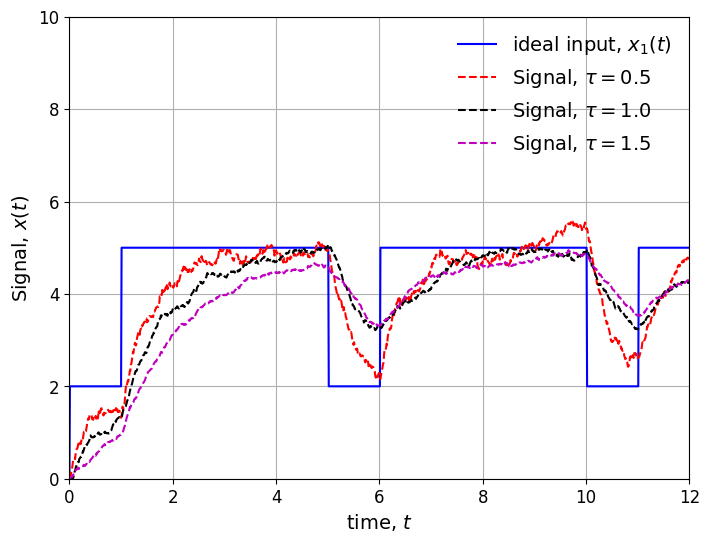

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pulse(t):
  x = 3*(1*( ((t%5) > 1)  and ( (t%5) < 5) )) + 2 # product of a boolean returns the integers 0 or 1
  return x


h = 0.01; Z = 12; T = int(Z/h)
tx = 0.5; N = 3
x = np.zeros((N,T)); y = np.zeros((N,T))

for i in range(N):
  tau = (i+1)*tx
  t = np.zeros(T); x1 = np.zeros(T)
  for j in range(1,T):
    t[j] = t[j-1] + h
    x1[j] = pulse(t[j-1])
    w = 2*np.sqrt(-2*np.log(np.random.random_sample()))\
                *np.cos(2*np.pi*np.random.random_sample())
    x[i,j] = x1[j] + w
    y[i,j] = y[i,j-1] + h/tau*(x[i,j-1] - y[i,j-1])


# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x[0,:],"r-",label = r"real input, $x(t)$")
plt.plot(t, x1,"b-",label = r"ideal input, $x_1(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel(r"Signal, $x(t)$",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 12, -5, 15])
plt.grid()
plt.show()

# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x1,"b-",label = r"ideal input, $x_1(t)$")
plt.plot(t, y[0,:],"r--",label = r"Signal, $\tau = 0.5$")
plt.plot(t, y[1,:],"k--",label = r"Signal, $\tau = 1.0$")
plt.plot(t, y[2,:],"m--",label = r"Signal, $\tau = 1.5$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel(r"Signal, $x(t)$",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 12, 0, 10])
plt.grid()
plt.show()

# Nomenclature

There is not just one methodology to adopt for system modeling, just as there is not just one notation to follow.

On the other hand, good graphical nomenclature can enrich the modeling process and understanding.

Below is a list of common symbols and their interpretations in the system modeling process.

<center>

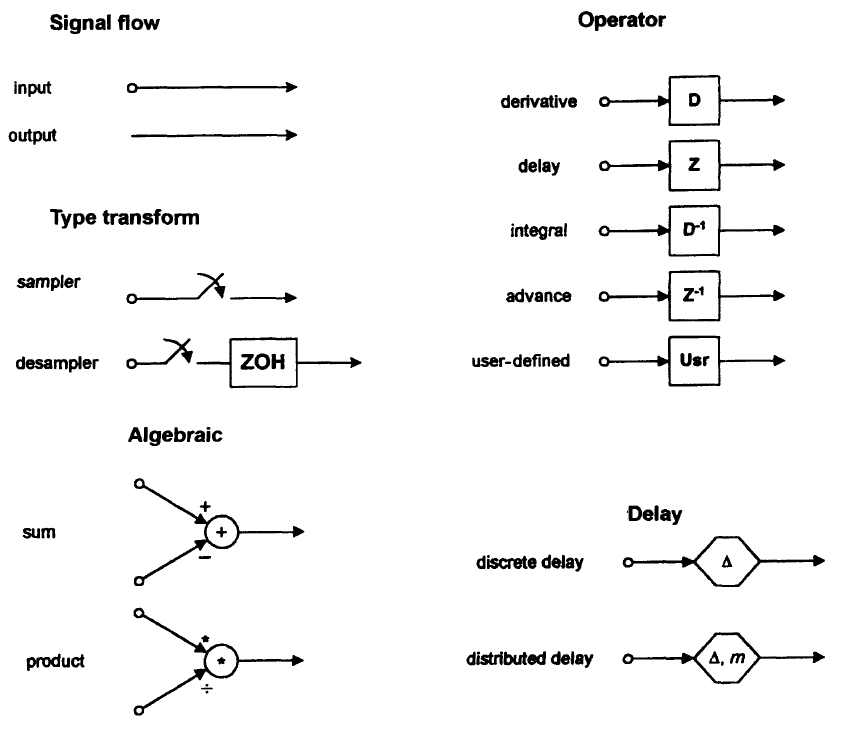
</center>

## Example 3
Consider a signal with two components: an ideal signal $x_1(t) = \cos(0.5t)$ and an additive white noise $w(t)$, so that the input is $x(t) = x_1(t) + w(t)$.

a) Calculate numerically the integral of $x(t)$, comparing it with the expected ideal results.

b) Calculate numerically the derivative of $x(t)$, comparing it with the expected ideal results.

c) Check the effects of placing a low-pass filter after the derivative.


**Solution**:

The routine used to calculate the three items is shown below:

Although noise is present, the integral of $x(t)$ almost follows the ideal result $z_1(t)$.

Here it can be observed that under the same noise variance, the fluctuations of the derivative are much more severe than those of the integral, shown in the previous figure.

To improve the derivative result, a low-pass filter with $\tau = 0.8$ is placed right after the signal output, as can be seen below.

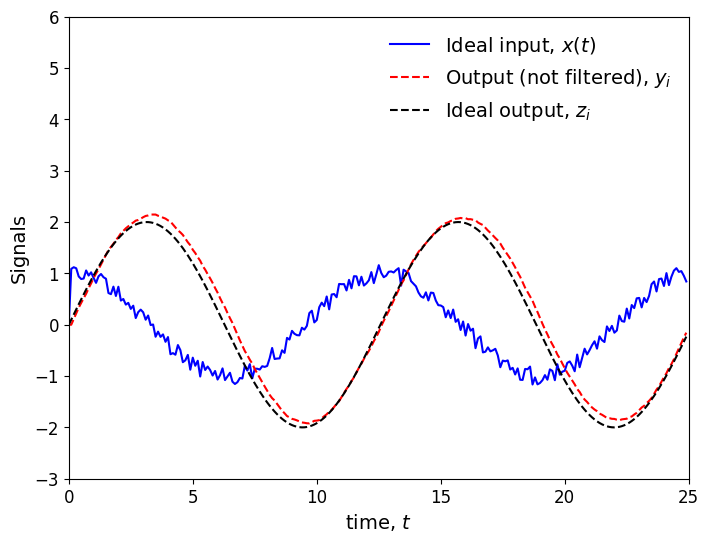

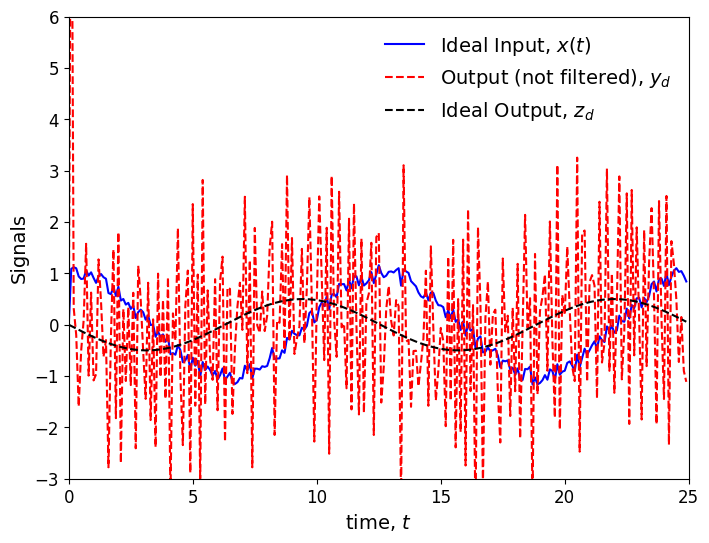

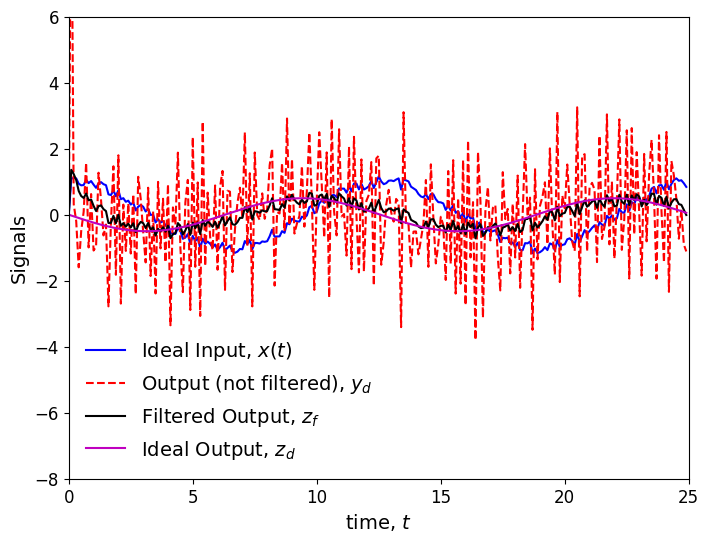

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.1; Z = 25; T = int(Z/h)
t = np.zeros(T)
x = np.zeros(T)
yi = np.zeros(T); yd = np.zeros(T);
zi = np.zeros(T); zf = np.zeros(T); zd = np.zeros(T)
tau = 0.8

for j in range(1,T):
    t[j] = t[j-1] + h
    zi[j] = 2*np.sin(0.5*t[j])
    zd[j] = -0.5*np.sin(0.5*t[j])
    w = np.sqrt(0.03) * (2*np.random.random_sample()-1);
    x[j] = np.cos(0.5*t[j-1]) + w
    yi[j] = yi[j-1] + h*x[j-1]
    yd[j] = (x[j] - x[j-1])/h
    zf[j] = zf[j-1] + h*(yd[j] - zf[j-1])/tau


# Figures
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Ideal input, $x(t)$")
plt.plot(t, yi,"r--",label = r"Output (not filtered), $y_i$")
plt.plot(t, zi,"k--",label = r"Ideal output, $z_i$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signals",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 25, -3, 6])
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Ideal Input, $x(t)$")
plt.plot(t, yd,"r--",label = r"Output (not filtered), $y_d$")
plt.plot(t, zd,"k--",label = r"Ideal Output, $z_d$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signals",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 25, -3, 6])
plt.show()


fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Ideal Input, $x(t)$")
plt.plot(t, yd,"r--",label = r"Output (not filtered), $y_d$")
plt.plot(t, zf,"k-",label = r"Filtered Output, $z_f$")
plt.plot(t, zd,"m-",label = r"Ideal Output, $z_d$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signals",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 25, -8, 6])
plt.show()

# Discrete Delays

Another special operator that was shown earlier is the discrete delays. Discrete delays are relatively simple and wait $\Delta$ units of time before sending the data to the output.

Mathematically, this can be converted into a difference equation, which can be written in continuous or discrete time, as follows:
$$ y(t) = x(t- \Delta)$$ $$ y(k) = x(k- \frac{\Delta}{\delta})$$

In this case $1/\delta$ is the sampling frequency.

## Example 4
Consider the system defined by the figure below. Assuming a sampling frequency of 2 samples per second, generate the output for a discrete delay $\Delta$ of 2 seconds, with an input $x(k) = 1 + \sin(k/10)$.

<center>

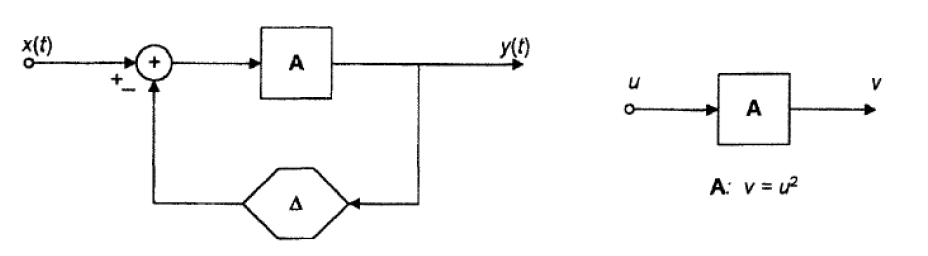
</center>


**Solution**:

With $\Delta = 2$, $y(t) = [x(t) – y(t – 2)]^2$ and since the sampling rate is $k = 2t$, we can write:

$$y(k) = [x(k) – y(k – 4)]^2$$

Using as initial conditions $y(0) = 1.877$; $y(1) = 2.014$; $y(2) = 1.417$; $y(3) = 0.571$ and $y(4) = 0$, the results can be achieved from the following script:

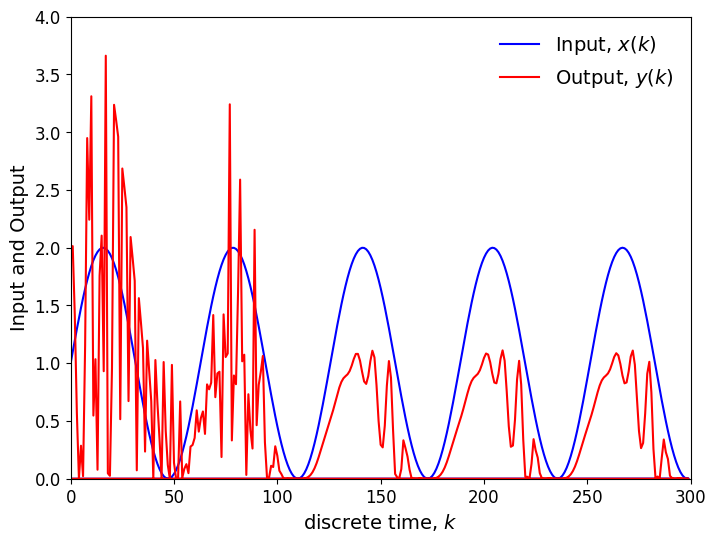

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

K = 300
k = np.zeros(K+1)
x = np.zeros(K+1); y =np.zeros(K+1)
x[0] = 1
y[0] = 1.887; y[1] = 2.014; y[2] = 1.417; y[3] = 0.571

for i in range(1,K):
  k[i] = i
  x[i] = 1 + np.sin(i/10)
  if (i > 4):
    y[i] = (x[i] - y[i-4])**2

# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(k, x,"b-",label = r"Input, $x(k)$")
plt.plot(k, y,"r-",label = r"Output, $y(k)$")
plt.xlabel(r"discrete time, $k$",fontsize=14)
plt.ylabel("Input and Output",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis(tuple([0, 300, 0, 4]))
plt.show()

# Distributed Delays

Discrete delays occur instantaneously, so their effects occur exactly Δ unit time later.

In contrast, distributed delays occur gradually over time.

By definition, the rate of change in the output of a distributed delay is proportional to the difference between the input and the output. The constant of proportionality is $1/\Delta$. Mathematically:

$$ \frac{d}{dx}y(t) = \frac{1}{\Delta}[x(t)-y(t)]$$

<center>

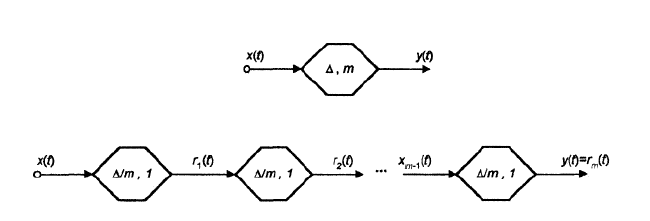
</center>

## Example 5

Produce an output from the distributed delay system shown in the figure, using an input $x(t) = \sin(0.5t)$ with an initial condition of 2 units in the first stage. Use $h = 0.1$ for simulation between $t=0$ and $t=6$.

<center>

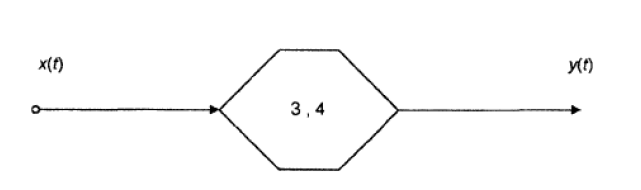
</center>

As a solution, the distributed delay system of the problem is equivalent to the one in the following figure, using first-order delays.

<center>

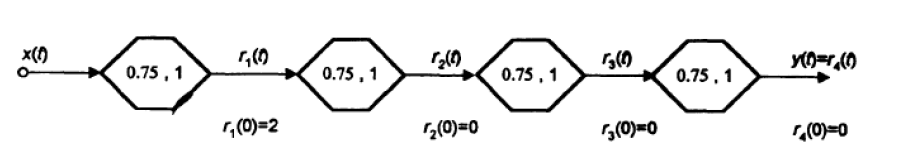
</center>

The following script simulates the system using the Euler method, where $1/\Delta = 4/3$.

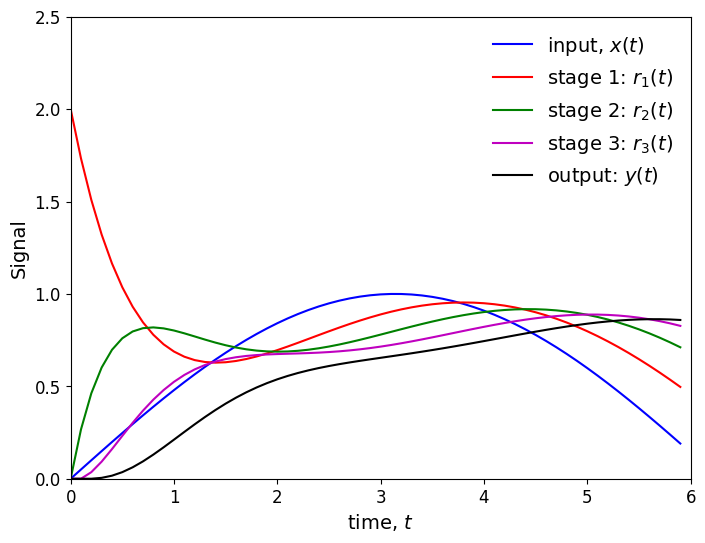

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Note the use lists instead of arrays to obtain the solutions.
t = [0]; y = [0];
r1 = [2]; r2 = [0]; r3 = [0]
x = [np.sin(0.5*t[-1])]
n = 60; h = 0.1

for i in range(1, n):
    t.append(t[-1] + h)
    y.append(y[-1] + 4/3*h*(r3[-1]-y[-1]))
    r3.append(r3[-1]+4/3*h*(r2[-1]-r3[-1]))
    r2.append(r2[-1]+4/3*h*(r1[-1]-r2[-1]))
    r1.append(r1[-1]+4/3*h*(x[-1]-r1[-1]))
    x.append(np.sin(0.5*t[-1]))

# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t,x,"b-",label=r"input, $x(t)$")
plt.plot(t,r1,"r-",label=r"stage 1: $r_1(t)$")
plt.plot(t,r2,"g-",label=r"stage 2: $r_2(t)$")
plt.plot(t,r3,"m-",label=r"stage 3: $r_3(t)$")
plt.plot(t,y,"k-",label=r"output: $y(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signal",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 6, 0, 2.5])
plt.show()

# System Integration

It is beneficial to model more than just physical engineering systems, since systems occur in life and in the physical and social sciences.

To demonstrate the application of these concepts, a simple biological system is employed.

To begin, a closed system is considered, which consists of three types of populations: adults (able to reproduce), young (developed but not yet able to reproduce), and immatures (in development).

The aim is to obtain the populations of adults a(t), young y(t), and the total population as a function of time.

A distributed delay of two months is assumed from the initial egg to the young stage.

The delay is spread over three equal stages (egg, larva, pupa). When the young individuals finally emerge, 60% die or are devoured.

For young who live, there are stages of childhood and adolescence until they reach the adult stage, which typically lasts approximately one month.

Of the adults that are formed, 20% die, and for those that survive, eggs are produced at a rate of 1/2 per adult.

The simulation diagram represents this problem. It is assumed that there are initially 6 adults, 6 young (including children and adolescents), and 6 immatures (such as eggs, larvae, and pupae) evenly distributed in each stage.

The goal is to develop a simulation model that determines the number of adults and juveniles, as well as the total population size, as a function of time. A simulation time step h = 5 days is assumed.


<center>

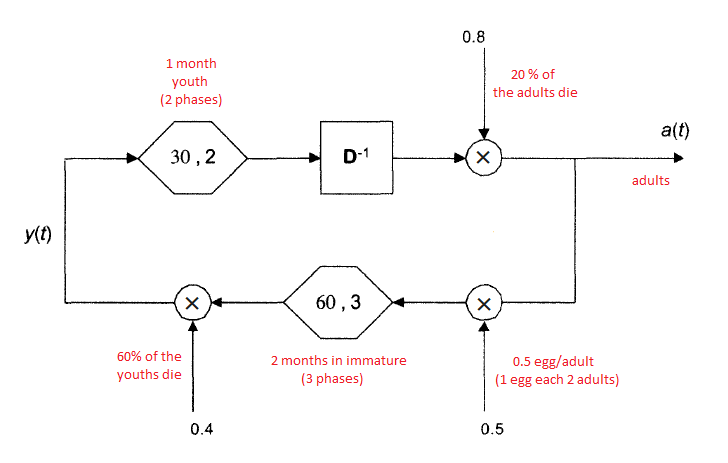
</center>

## Example 6

The following diagram is used to simulate this system, considering a discrete delay. The following difference equations describe the system:

<center>

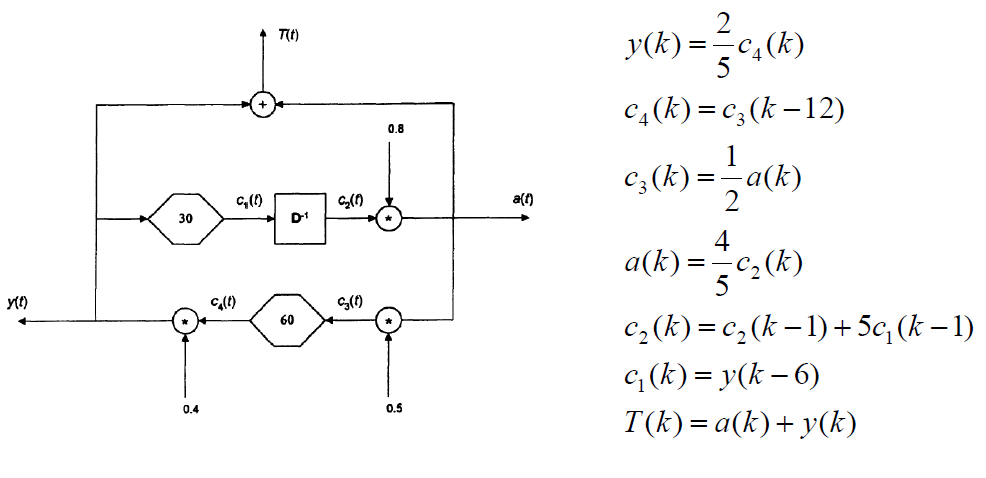
</center>

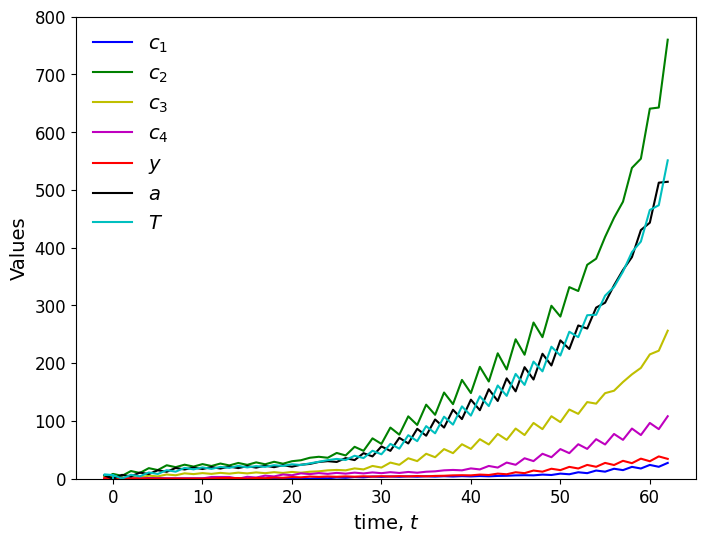

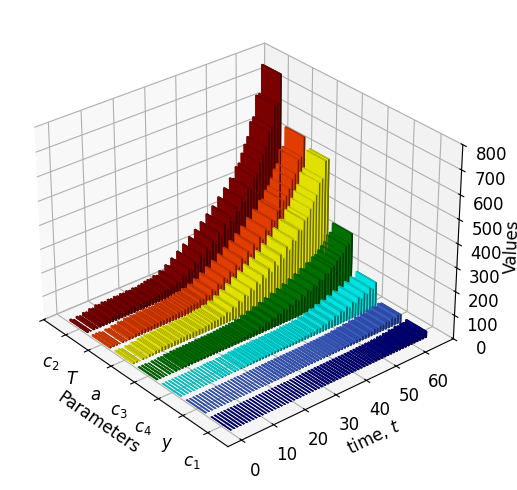

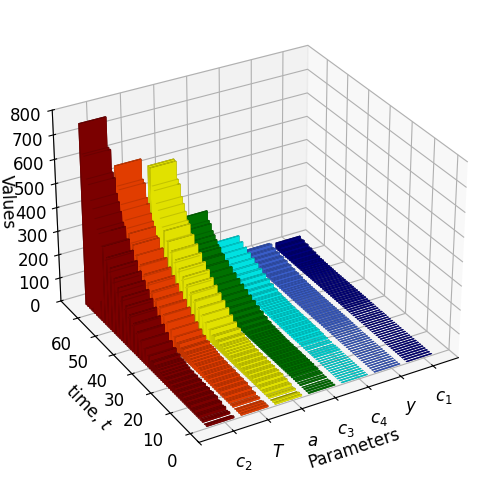

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

K = 65; t0 = 12; tf = t0 + K;

a = np.zeros(tf)
a[t0] = 6
c1 = np.zeros(tf)
c1[t0] = 0.16
c2 = np.zeros(tf)
c2[t0] = 7.5
c3 = np.zeros(tf)
c3[0:t0] = 0.5; c3[t0] = 3
c4 = np.zeros(tf)
c4[t0] = 0.5
T = np.zeros(tf)
T[t0] = 6.4
y = np.zeros(tf)
y[t0-6:t0] = 1; y[t0] = 1

kk = np.zeros(tf)

for k in range(t0,tf-1):
  kk[k+1] = k-t0-1
  y[k+1] = 0.4*c4[k]
  c4[k+1] = c3[k-12]
  c3[k+1] = 0.5*a[k]
  a[k+1] = 0.8*c2[k]
  c2[k+1] = c2[k-1] + 5*c1[k-1]
  c1[k+1] = y[k-6]
  T[k+1] = a[k] + y[k]

# Figure
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(kk, c1,"b-",label = r"$c_1$")
plt.plot(kk, c2,"g-",label = r"$c_2$")
plt.plot(kk, c3,"y-",label = r"$c_3$")
plt.plot(kk, c4,"m-",label = r"$c_4$")
plt.plot(kk, y,"r-",label = r"$y$")
plt.plot(kk, a,"k-",label = r"$a$")
plt.plot(kk, T,"c-",label = r"$T$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Values",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.ylim([0, 800])
plt.show()

Z = np.concatenate((np.vstack(c2[t0:tf]), np.vstack(T[t0:tf]), np.vstack(a[t0:tf]), np.vstack(c3[t0:tf]), np.vstack(c4[t0:tf]), np.vstack(y[t0:tf]), np.vstack(c1[t0:tf])), axis=1)
cols = ["","$c_2$","$T$","$a$","$c_3$","$c_4$","$y$","$c_1$"]

# 3D Figure - version 1
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
lx = len(Z[0])
ly = len(Z[:,0])
xpos = np.arange(0, lx, 1)
ypos = np.arange(0, ly, 1)
pos = 0.5
xpos, ypos = np.meshgrid(xpos + pos, ypos + pos)

# Positions
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros(lx*ly)

p1 = 0.5; p2 = 0.8

# Determining the thicknesses
dx = p2*np.ones_like(zpos)
dy = p1*np.ones_like(zpos)
dz = Z.flatten()

# Colors
colors = ['darkred', 'orangered', 'yellow', 'green', 'cyan', 'royalblue','darkblue']*ly

# Figures
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors)

# Axis
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_xlabel("Parameters")
ax.set_ylabel("time, $t$")
ax.set_zlabel("Values", labelpad=1)
ax.set_zlim([0, 800])
ax.view_init(elev=30, azim=320.)
plt.show()

# 3D Figure - version 2
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
lx = len(Z[0])
ly = len(Z[:,0])
xpos = np.arange(0, lx, 1)
ypos = np.arange(0, ly, 1)
pos = 0.5
xpos, ypos = np.meshgrid(xpos + pos, ypos + pos)

# Positions
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros(lx*ly)

p1 = 0.5; p2 = 0.8

# Determining the thicknesses
dx = p2*np.ones_like(zpos)
dy = p1*np.ones_like(zpos)
dz = Z.flatten()

# Colors
colors = ['darkred', 'orangered', 'yellow', 'green', 'cyan', 'royalblue','darkblue']*ly

# Figures
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors)

# Axis
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_xlabel("Parameters")
ax.set_ylabel("time, $t$")
ax.set_zlabel("Values", rotation=90, labelpad=1)
ax.set_zlim([0, 800])
ax.view_init(elev=30., azim=-120.)
plt.show()

# Linear Systems

As seen, the discrete delay is a special case of a linear difference equation. It can also be proved that a distributed delay is a special case of a linear differential equation.

Linear systems are interesting for engineering, and many nonlinear systems are linearized around a point of interest so that they can be solved.

In a linear system, the superposition theorem can be applied, i.e., $y(t) = f(x_1,x_2) = f(x_1,0)+f(0,x_2)$. This leads to the concept of a transfer function, defined as the ratio of its output to its input. If the system is linear, the transfer function is independent of the input and output.



## Example 7

Consider a system defined by the following block diagram, in which y(t) is the output and x(t) is the input of the system. Find the transfer function and numerically solve the system with initial conditions $y(0) = 5$ and $\dot{y}(0) = -2$.

The input is a ramp defined by $x_1(t) = 0.5t$, added to a Gaussian white noise with variance $\sigma^2 = 0.25$.

<center>

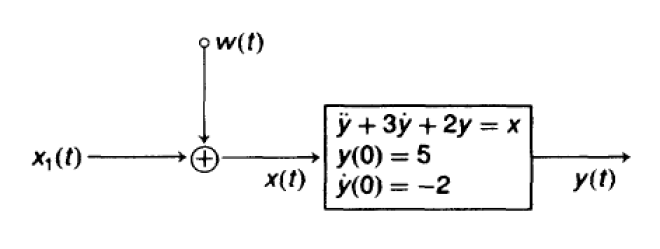
</center>

**Solution**:

As a solution, to find the transfer function, one can replace all derivatives with their respective orders by a notation $D$.

Thus,

$$ x(t) = D^2y + 3Dy + 2y$$

$$ = (D^2 + 3D +2)y(t)$$

$$ = (D+1)(D+2)y(t)$$

And the transfer function is:

$$\frac{y(t)}{x(t)} = \frac{1}{D^2 + 3D +2} = \frac{1}{(D+1)(D+2)} = \frac{1}{(D+1)}= \frac{1}{(D+2)}$$

As seen, there are three ways to represent this transfer function, and to study them, the following script was developed:

<center>

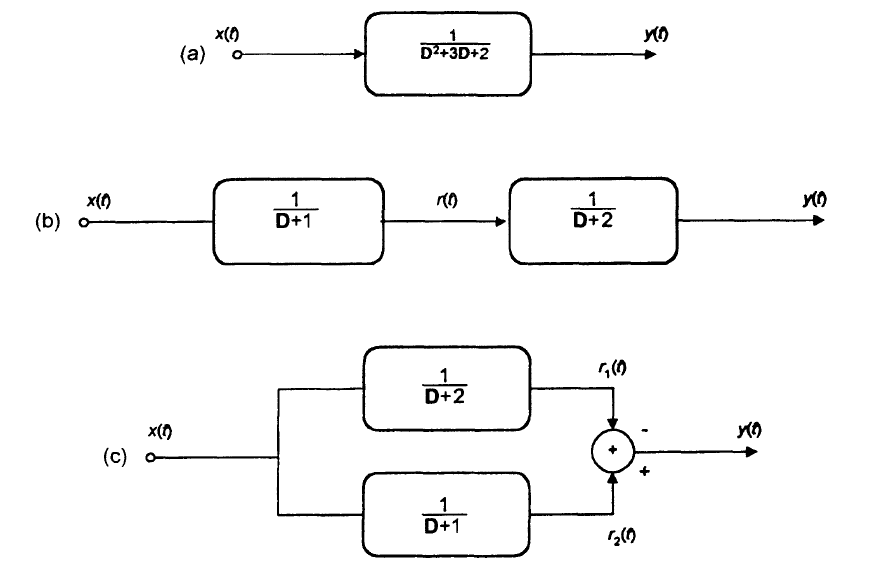
</center>

For the solution via Method 1 (diagram a), an intermediate variable is used to transform the second-order differential equation into a first-order one

$$ \dot{r}(t) = 3r(t)+2y(t) = x(y)$$

$$ \dot{y}(t) = r(t)$$

And discretizing using Euler:

$$ r(k+1) = r(k) + h[x(k) -3r(k)-2y(k)]$$

$$ y(k+1) = y(k) + hr(k)$$

For the solution via Method 2 (diagram b), an intermediate variable $r(t)$ is defined, with $r(0) = \dot{y}(0) + 2y(0) = -2 + 2(5) =8$

$$ \dot{r}(t) +r(t) = x(t)$$

$$ \dot{y}(t) + 2y(t) = r(t)$$

Discretizing using Euler:

$$ r(k+1) = r(k) + h[x(k) -r(k)]$$

$$ y(k+1) = y(k) + h[r(k) -2y(k)]$$

Finally, for the solution via Method 3 (diagram c), one can write the following equations:

$$ \dot{r}_1(t) +2r_1(t) = x(t)$$

$$ \dot{r}_2(t) +r_2(t) = x(t)$$

$$ y(t) = r_2(t)- r_1(t)$$

Discretizing via Euler and using as initial conditions $r_1(0) = 3$ and $r_2(0) = 8$:

$$ r_1(k+1) = r_1(k) + h[x(k) -2r_1(k)]$$

$$ r_2(k+1) = r_2(k) + h[x(k) -r_2(k)]$$

$$ y(k+1) = r_2(k) -r_1(k)$$


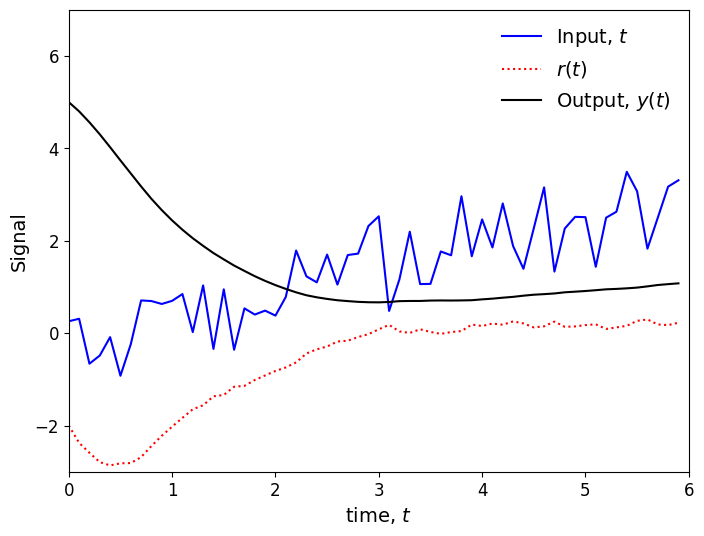

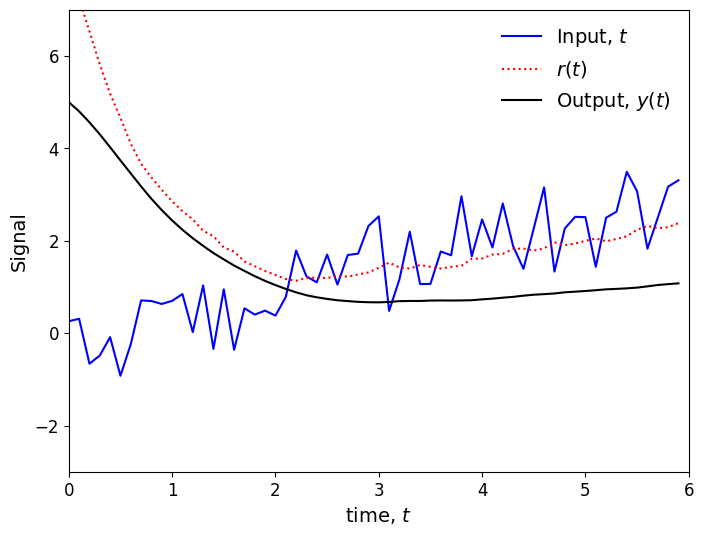

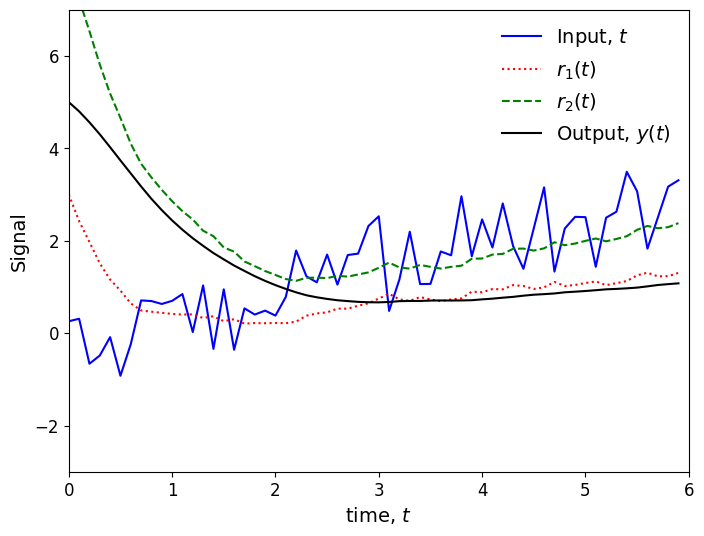

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.1; Z = 6; N = int(Z/h)
t = np.zeros(N); x = np.zeros(N);
r1 = np.zeros(N); y1 = np.zeros(N);
r2 = np.zeros(N); y2 = np.zeros(N);
r3a = np.zeros(N); r3b = np.zeros(N); y3 = np.zeros(N)

r1[0] = -2; r2[0] = 8; r3a[0] = 3;
r3b[0] = 8; y1[0] = 5; y2[0] = 5; y3[0] = 5
x[0] = 0.5*np.sqrt(-2*np.log(np.random.random_sample()))\
                *np.cos(2*np.pi*np.random.random_sample())

for j in range(N-1):
  t[j+1] = t[j] + h
  x[j+1] = 0.5*t[j] + 0.5*np.sqrt(-2*np.log(np.random.random_sample()))\
              *np.cos(2*np.pi*np.random.random_sample())
  # Method 1
  r1[j+1] = r1[j] + h*(x[j] - 3*r1[j] - 2*y1[j])
  y1[j+1] = y1[j] + h*r1[j]
  # Method 2
  r2[j+1] = r2[j] + h*(x[j] - r2[j])
  y2[j+1] = y2[j] + h*(r2[j] - 2*y2[j])
  # Method 3
  r3a[j+1] = r3a[j] + h*(x[j] - 2*r3a[j])
  r3b[j+1] = r3b[j] + h*(x[j] - r3b[j])
  y3[j+1] = r3b[j+1] - r3a[j+1]

# Figures
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Input, $t$")
plt.plot(t, r1,"r:",label = r"$r(t)$")
plt.plot(t, y1,"k-",label = r"Output, $y(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signal",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 6, -3, 7])
plt.savefig("Fig1.png")
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Input, $t$")
plt.plot(t, r2,"r:",label = r"$r(t)$")
plt.plot(t, y2,"k-",label = r"Output, $y(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signal",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 6, -3, 7])
plt.savefig("Fig2.png")
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, x,"b-",label = r"Input, $t$")
plt.plot(t, r3a,"r:",label = r"$r_1(t)$")
plt.plot(t, r3b,"g--",label = r"$r_2(t)$")
plt.plot(t, y3,"k-",label = r"Output, $y(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signal",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 6, -3, 7])
plt.savefig("Fig3.png")
plt.show()

# Motion Control Models

Control system design is the central area of ​​application for modeling engineering. Of these, motion control is the most important, with DC servomotors being the primary focus.

The DC servomotor is a transducer, in the sense that it transforms electrical energy (in the form of electrical current) into mechanical energy (in the form of motion).

The system is shown in the following figure:

<center>

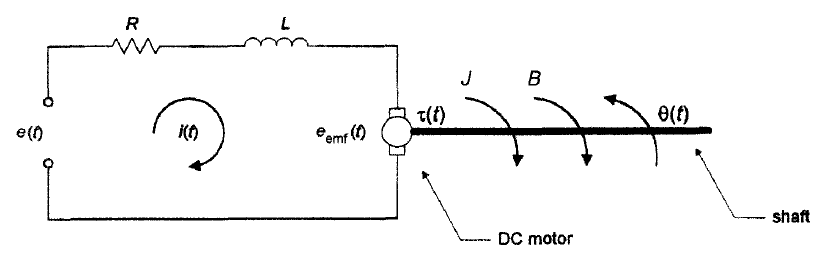

</center>

Thus, the supply of a voltage $e(t)$ creates a current $i(t)$ through a series of circuits consisting of a resistance R and an inductance L of the motor windings.

The movement of the motor creates a torque $\tau(t)$, which resists the inertial mass characterized by the moment of inertia $J$ and the friction force (described by the coefficient of friction $B$). The movement gives an angular velocity $\omega(t)$. The model is:

$$ \tau(t) = K_1i(t)$$ $$ e_{emf}(t) = K_2\omega (t)$$ $$ e(t) = Ri(t) + L\frac{di}{dt}e_{emf}(t)$$ $$ \tau(t) = J\frac{d\omega}{dt}+B\omega (t)$$ $$\omega (t) = \frac{d\theta}{dt}$$

The simplified block diagram of a DC motor is given below:

<center>

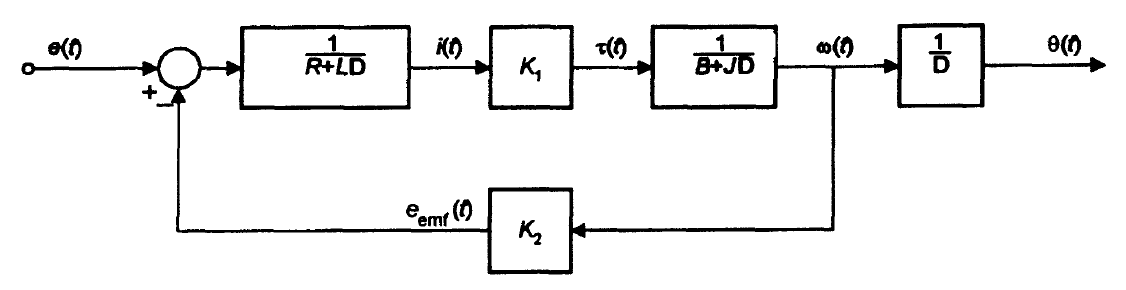
</center>

Each of the above equations can be converted to the appropriate difference equations using Euler:

$$ \theta (k+1) = \theta (k) + h\omega (k)$$ $$ \omega (k+1) = \omega (k) + \frac{h}{J}[\tau (k) - B\omega (k)$$ $$ i(k+1) = i(k) + \frac{h}{L}[e(k) - e_{emf}(k) - Ri(k)$$ $$\tau (k) = K_1i(k)$$ $$e_{emf}(k) = K_2\omega (k)$$

## Example 8

Simulate the motion of a DC motor with the following parameters: $K_1 = 1000$ (torque constant), $K_2 = 5$ (back electromotive force), $J = 3$, $L = 10$, $B = 30$, and $R = 100$. Use a step of $0.01$.

The input is a pulse train with a $\pm 5$ V amplitude, a frequency of $1/3$ Hz, and a duty cycle of $50 \%$. Assume additive white Gaussian noise of $\sigma^2 = 0.25$.

**Solution**:

As a solution, the input can be obtained with the function *pulse2(t)*, described in the script below.

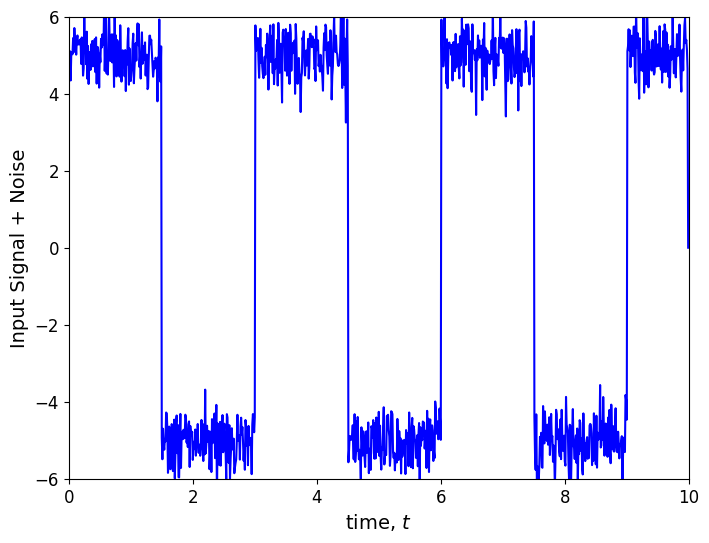

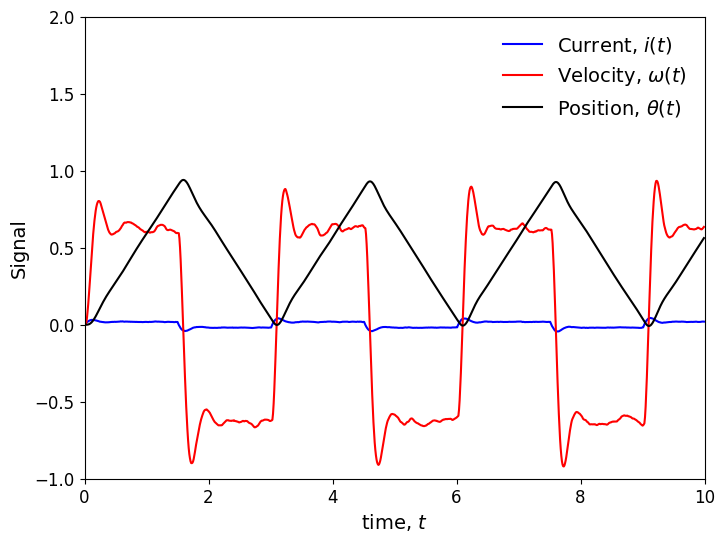

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pulse2(t):
  x = 5*( (-1)**np.floor(t/1.5) )
  return x


# System Parameters
K1 = 1000; K2 = 5; J = 3
L = 10; B = 30; R = 100

# Simulation Parameters
tn = 10; h = 0.01; N = int(tn/h)
t = np.zeros(N)

# Model Parameters
i = np.zeros(N); omega = np.zeros(N); teta = np.zeros(N); E = np.zeros(N)
tau = 0; Eemf = 0

for j in range(N-1):
   t[j+1] = t[j] + h;
   w = 0.5*np.sqrt(-2*np.log(np.random.random_sample()))\
            *np.cos(2*np.pi*np.random.random_sample())
   E[j] = pulse2(t[j]) + w
   i[j+1] = i[j] + h/L*(E[j] - Eemf - R*i[j])
   omega[j+1] = omega[j] + h/J*(tau-B*omega[j])
   teta[j+1] = teta[j] + h*omega[j]
   tau = K1*i[j]
   Eemf = K2*omega[j]

# Figures
fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t[0:len(E)], E,"b-")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Input Signal + Noise",fontsize=14)
plt.axis([0, 10, -6, 6])
plt.show()

fig = plt.subplots()
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = "12"
plt.plot(t, i,"b-",label = r"Current, $i(t)$")
plt.plot(t, omega,"r-",label = r"Velocity, $\omega(t)$")
plt.plot(t, teta,"k-",label = r"Position, $\theta(t)$")
plt.xlabel(r"time, $t$",fontsize=14)
plt.ylabel("Signal",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 10, -1, 2])
plt.show()

# Exercises

1. Simulate the continuation of Example 6 considering distributed delays with uniformly distributed initial conditions: $a(0) = 6, r_5(0) = 3, r_4(0) = 3, y(0) = 2, r_2(0) = 2, r_1(0) = 2$.

2. Simulate the following system with $0 \le t \le 12$, $e(t) = 4 \sin(3t)$ and $w(t)$ being a uniform additive noise in the interval $[-1,~1[$ and $f = 2$ samples per second. The signal $x(t) = e(t) + w(t)$ and the initial conditions are: $y(0) = 0, r_1(0) = 5, r_2(0) = 4$.

<center>

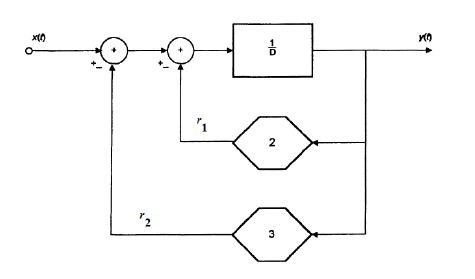
</center>

# References

[1] SEVERANCE, F. L., System Modeling and Simulation, John Wiley & Sons, 2001. (Some figures shown in this lecture were taken from this reference)